In [1]:
import networkx as nx #do wizualizacji sieci, wyodrebniania miar
import matplotlib.pyplot as plt #do wizualizacji sieci
from pyvis.network import Network #do wizualizacji sieci
from operator import itemgetter #do sortowania słownika
import pandas as pd #do wczytania danych
import numpy as np #do uzyskania wektorów

In [2]:
data = pd.read_csv(
    "data.csv",
    dtype={"link_flair_text": "string"}
)
data = data[data["author"]!="[deleted]"]
data["parent_id_clean"] = data["parent_id"].str.replace("t1_", "").str.replace("t3_", "")
data.head()

,author,over_18,title,body,id,link_id,parent_id,subreddit,subreddit_id,subreddit_type,name,ups,downs,score,reddit_name_prefix,link_flair_text,type,created_date,postac,parent_id_clean
0,cysenberg,NaN,NaN,I can't believe this sub is devoted to that ho...,dittstm,t3_6gvhln,t3_6gvhln,cyrus,t5_2rofl,NaN,t1_dittstm,1,NaN,1,NaN,<NA>,comments,2017-06-13,MileyCyrus,6gvhln
1,cy_guy,NaN,NaN,?? what did ido???,ditveid,t3_6gvhln,t1_dittstm,cyrus,t5_2rofl,NaN,t1_ditveid,1,NaN,1,NaN,<NA>,comments,2017-06-13,MileyCyrus,dittstm
2,cysenberg,NaN,NaN,The sub not your post lol. On the sidebar it s...,dityjgt,t3_6gvhln,t1_ditveid,cyrus,t5_2rofl,NaN,t1_dityjgt,1,NaN,1,NaN,<NA>,comments,2017-06-13,MileyCyrus,ditveid
3,cy_guy,NaN,NaN,oh thats fuckin stupid,dityugh,t3_6gvhln,t1_dityjgt,cyrus,t5_2rofl,NaN,t1_dityugh,2,NaN,2,NaN,<NA>,comments,2017-06-13,MileyCyrus,dityjgt
4,TBD-101,NaN,NaN,Cyrus is the best,f5o6jgd,t3_doilrx,t3_doilrx,cyrus,t5_2rofl,public,t1_f5o6jgd,10,NaN,10,NaN,<NA>,comments,2019-10-29,MileyCyrus,doilrx


In [3]:
removed_text = {"[deleted]", "[removed]", "deleted", "removed", ""}
known_bots = {
    "AutoModerator", "autotldr", 
    "tweettranscriberbot", "transcribersofreddit",
    "RemindMeBot", "twitterInfo_bot", 
    "hannahmontana-ModTeam", "mileycyrus-ModTeam", "miley-ModTeam", "QueenMileyCyrus-ModTeam",
    'killbot2_0',
    'bruh__bot',
    'bot-the-builder',
    'phonebatterylevelbot',
    'smile-bot-2019',
    'patrick_bot3',
    'june-bot',
    'exclaim_bot',
    'yahoo_bot',
    'a_compliment_bot',
    'autourbanbot',
    'instagrambot',
    'DealWithItbot',
    'totes_meta_bot',
    'gifv-bot',
    'youtubefactsbot',
    'sneakpeekbot',
    'imguralbumbot',
    'anti-gif-bot',
    'I_am_a_haiku_bot',
    'tweettranscriberbot',
    'serendipitybot',
    'lerobinbot',
    'the_timezone_bot',
    'reversenwordbot',
    'redditspeedbot',
    'timee_bot',
    'haikusbot',
    'twitterInfo_bot',
    'wikipedia_answer_bot',
    'songacronymbot',
    'of_patrol_bot',
    'alphabet_order_bot',
    'metric_robot',
    'outline_link_bot',
    'SpambotSwattr',
    'Cinnabot2026'
}

removed_body_mask = (data["type"] == "comments") & data["body"].fillna("").astype(str).str.strip().str.lower().isin(removed_text)
removed_title_mask = (data["type"] == "posts") & data["title"].fillna("").astype(str).str.strip().str.lower().isin(removed_text)

cleaned_author = data["author"].fillna("").astype(str).str.strip()
bot_mask = cleaned_author.isin(known_bots) | cleaned_author.str.lower().isin(removed_text)
data = data.loc[~removed_body_mask & ~removed_title_mask & ~bot_mask].copy()

In [4]:
posts = data[data["type"] == "posts"]

posts = posts[["id", "author", "title", "body", "score"]]
 
comments = data[data["type"] == "comments"]

comments = comments[["subreddit", "postac", "parent_id_clean", "id", "author", "title", "body", "score"]]
 
merged = posts.merge(

    comments,

    left_on = "id",

    right_on = "parent_id_clean",

    how="left",

    suffixes = ("_post", "_comment"),

).drop("parent_id_clean", axis=1)

merged.head(10)
 

,id_post,author_post,title_post,body_post,score_post,subreddit,postac,id_comment,author_comment,title_comment,body_comment,score_comment
0,1rn81s,TeleSpectacular,Miley Cyrus - Wrecking Ball live American Musi...,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1y73hf,dan_nexus,The App Store has really gone down lately...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3lnj5u,Sszjme,Cydia Download | The Simplest way to get Cydia...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4tqwge,HHH888N,Miley Cyrus Nude and all other celebs naked pr...,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6gvhln,cy_guy,My name is Cyrus! :D,NaN,2,cyrus,MileyCyrus,dittstm,cysenberg,NaN,I can't believe this sub is devoted to that ho...,1.0
5,7kk1lr,emmieeichlerjoa,Find the best prices in hundred hotels.,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7slsux,FunArcade,Cyrus Gold,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,88xzcc,superbhuboutreach,Where is Baxter Neal Helson Now? Tish Cyrus Ex...,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9t3gtq,Rayanparker726,Hi cyrus fans,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9uxqwe,suckthezucc,Hello cHildRen,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
pair_occurance = merged.groupby(["author_post", "author_comment"]).size().reset_index(name="count")
pair_occurance

,author_post,author_comment,count
0,--daddylonglegs--,--daddylonglegs--,2
1,--daddylonglegs--,0k-boomer,1
2,--daddylonglegs--,Alviana_rose,1
3,--daddylonglegs--,AstroManiac78,1
4,--daddylonglegs--,Cazok_YT,1
...,...,...,...
33665,zziuht,Profound_Shit,1
33666,zziuht,badword4,1
33667,zziuht,lizard_king_rebirth,1
33668,zziuht,thescreenguy,1


In [6]:
n = 3
filtered = pair_occurance[pair_occurance["count"] > n]
filtered

,author_post,author_comment,count
210,9your,Christanygacha,9
269,9your,dianahair23,9
377,AbjectScarcity3425,PrestigiouShadows,5
394,Acceptable_Grape748,Intelligent_Hawk_622,5
397,Acceptable_Grape748,Longjumping-Hawk1664,4
...,...,...,...
33372,you_sername,JS963554,19
33422,you_sername,StorFiskarn1337,5
33501,you_sername,you_sername,4
33606,zona213,JS963554,10


In [7]:
merged_filtered_out = merged.merge(
    filtered[["author_post", "author_comment"]],
    on=["author_post", "author_comment"],
    how="right",
    indicator=True
).drop(columns="_merge")
merged_filtered_out = merged_filtered_out[
    merged_filtered_out["author_post"] != merged_filtered_out["author_comment"]
]

In [8]:
# unikalne pary author - postać
tmp = data[["author", "postac"]].drop_duplicates()

# lista postaci dla każdego autora
agg = tmp.groupby("author")["postac"].apply(set).reset_index()

# klasyfikacja
def classify(x):
    if x == {"MileyCyrus"}:
        return "MileyCyrus"
    elif x == {"HannahMontana"}:
        return "HannahMontana"
    else:
        return "Both"

agg["type"] = agg["postac"].apply(classify)

# final df
df_authors = agg[["author", "type"]]

In [9]:
G = nx.from_pandas_edgelist(merged_filtered_out, source="author_comment", target="author_post", edge_attr="score_comment", create_using=nx.DiGraph())
 
type_map = df_authors.set_index("author")["type"].to_dict()

node_colors = []

for node in G.nodes():
    if node in type_map:
        if type_map[node] == "MileyCyrus":
            node_colors.append("lightgreen")
        elif type_map[node] == "HannahMontana":
            node_colors.append("lightblue")
        else:  # Both
            node_colors.append("orange")

C:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\networkx\drawing\nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


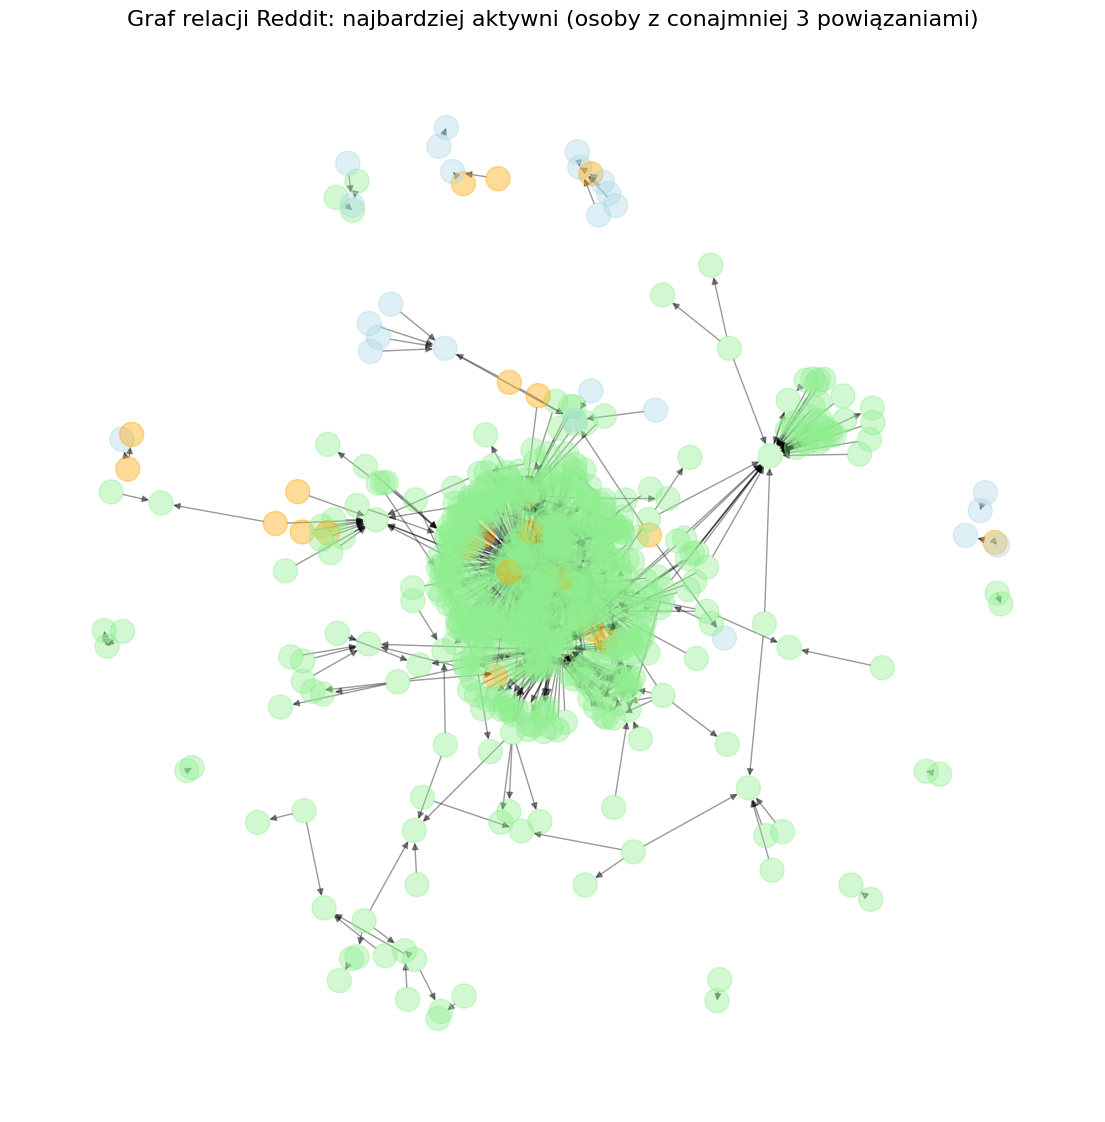

In [10]:
plt.figure(figsize=(14, 14))

pos = nx.spring_layout(G)

degrees = dict(G.degree())
node_sizes = [v * 40 for v in degrees.values()]

node_colors = node_colors

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    alpha=0.4
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.4,
    arrows=True,
    arrowsize=10
)

# nx.draw_networkx_labels(
#    G,
#   pos,
#    font_size=10,
#    font_weight="bold",
#    font_color="red"
# )

plt.title(f"Graf relacji Reddit: najbardziej aktywni (osoby z conajmniej {n} powiązaniami)", fontsize=16)
plt.axis("off")

plt.show()

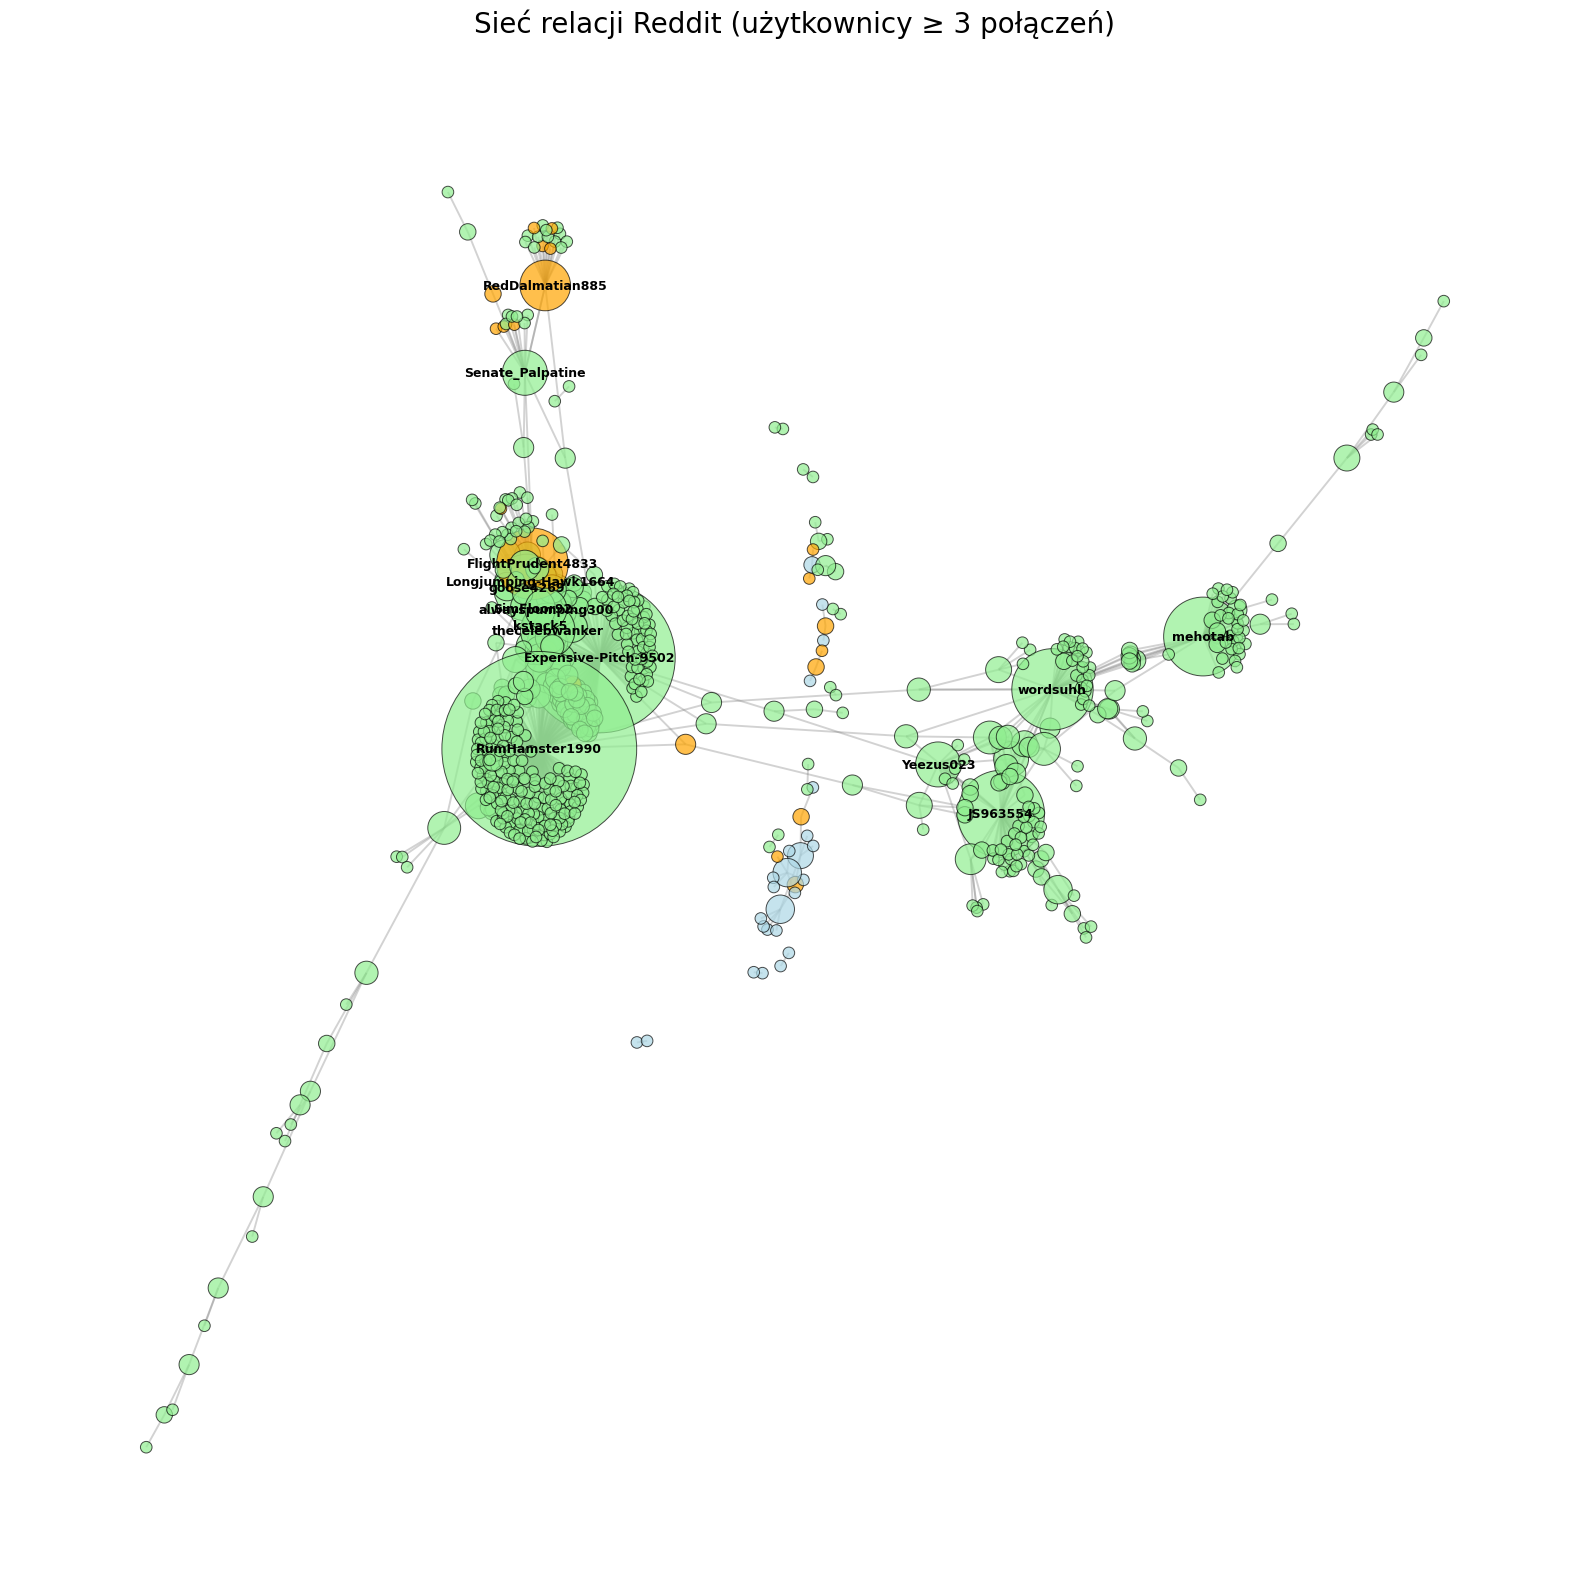

In [16]:
plt.figure(figsize=(16,16), facecolor="white")
ax = plt.gca()

pos = nx.spring_layout(
    G,
    k=1.2,              # większy rozrzut
    iterations=200,
    seed=42
)

degrees = dict(G.degree())

node_sizes = [degrees[n]*70 for n in G.nodes()]

# zwiększenie widoczności wag
edge_widths = [
    np.log1p(G[u][v].get("weight",1))*2
    for u,v in G.edges()
]

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.35,          # było 0.15
    edge_color="gray",   # zamiast white
    arrows=False
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.plasma,
    alpha=0.7,
    edgecolors="black",
    linewidths=0.7
)

top_nodes = sorted(
    degrees,
    key=degrees.get,
    reverse=True
)[:15]

labels = {n:n for n in top_nodes}

nx.draw_networkx_labels(
    G,
    pos,
    labels,
    font_size=9,
    font_weight="bold",
    font_color="black"
)

plt.title(
    f"Sieć relacji Reddit (użytkownicy ≥ {n} połączeń)",
    fontsize=20,
    pad=20
)

plt.axis("off")
plt.tight_layout()
plt.show()